In [ ]:
# === Colab: leer columna "Ticker" de un Google Sheet y devolver lista única (sin duplicados) ===
# Nota: si te da "permission denied", abre el Google Sheet y compártelo con tu cuenta de Google
# (o ponlo como "Anyone with the link can view") y vuelve a correr.

!pip -q install gspread

import re
import pandas as pd
import gspread
from google.colab import auth
from google.auth import default

SHEET_URL = "https://docs.google.com/spreadsheets/d/1YgawksW3DtyR9SQrzJmJcL8AqhiULUXWd0eQw0GEx7E/edit?gid=1009315469#gid=1009315469"
GID = 1009315469
TICKER_COL = "Ticker"

# --- Auth (Colab) ---
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# --- Helpers: extraer sheet_id de la URL ---
m = re.search(r"/spreadsheets/d/([a-zA-Z0-9-_]+)", SHEET_URL)
if not m:
    raise ValueError("No pude extraer el spreadsheet_id de la URL.")
SHEET_ID = m.group(1)

# --- Abrir spreadsheet y worksheet por gid ---
sh = gc.open_by_key(SHEET_ID)
ws = next((w for w in sh.worksheets() if w.id == int(GID)), None)
if ws is None:
    raise ValueError(f"No encontré una worksheet con gid={GID}.")

# --- Cargar datos a DataFrame ---
df = pd.DataFrame(ws.get_all_records())

if TICKER_COL not in df.columns:
    raise ValueError(f"No existe la columna '{TICKER_COL}'. Columnas encontradas: {list(df.columns)}")

# --- Limpiar y quitar duplicados preservando el orden ---
s = (
    df[TICKER_COL]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({"": pd.NA, "NA": pd.NA, "N/A": pd.NA, "NAN": pd.NA, "NONE": pd.NA, "NULL": pd.NA})
    .dropna()
)

unique_tickers = s[~s.duplicated()].tolist()

# --- Salida: lista (una por línea) + DataFrame listo para copiar/pegar ---
print("Tickers únicos (sin duplicados):\n")
print("\n".join(unique_tickers))

unique_df = pd.DataFrame({"Ticker": unique_tickers})
display(unique_df)

Tickers únicos (sin duplicados):

ADM
AXP
BA
BMY
CI
CNC
CTRA
CTVA
EL
EMR
ES
FCX
GWW
HPQ
LEN
LHX
MAA
MSI
PLD
SNA
WM
CPRT
FTNT
GOOG
HSIC
ILMN
JKHY
MDLZ
ON
PYPL
QRVO
TROW
TSLA
XLRE
XLE
AAP
ALB
AVB
BBY
BEN
DHR
DLR
FRT
GIS
HII
MCK
MKC
PAYC
PM
RVTY
SPGI
SYY
UDR
VZ
WRB
WST
XOM
CDNS
EVRG
LKQ
NXPI
ODFL
PEP
TER
VRSN
WYNN
ABT
ALL
AON
ATO
CB
CBRE
CL
D
DG
DGX
DUK
EPAM
ESS
FDS
HLT
KMI
L
LH
LLY
LYB
MS
MTD
NI
PPL
RTX
SRE
TDY
TRV
AKAM
ALGN
CME
EXC
HOLX
HST
KLAC
LNT
MCHP
NDSN
NVDA
PANW
REGN
VRSK
XLK
XLU
AES
AEE
BK
BRK-B
BXP
C
COP
CPT
CVX
DVN
ECL
ETN
GE
HAL
HPE
IBM
INVH
J
MMM
RSG
SHW
SO
STZ
TEL
TFX
WMB
CHRW
INCY
INTC
KHC
LRCX
MU
REG
AIZ
AMT
APTV
BSX
CCI
CE
CFG
CMA
CRL
DE
FTV
GPC
HSY
IRM
JCI
JNJ
KEY
LVS
MOH
MTB
OKE
PH
RF
ROL
TJX
TPR
ACGL
ADSK
APA
CHTR
FANG
FOXA
MTCH
PFG
STX
WBD
WDC
ZION
AME
BAC
BDX
CAT
ED
EIX
GM
HIG
LUV
MOS
MRK
MSCI
NKE
NUE
PG
PNR
PRU
PSX
ROK
T
TSN
TYL
UNH
URI
WHR
YUM
ZBH
AMAT
BKNG
NDAQ
TMUS
TRMB
VTRS
XLF
SPY
BF-B
DHI
DIS
EXR
LMT
MET
MO
NEM
ORCL
PCG
PKG
PNW
TGT
TRGP
CINF
CSGP
FAST
MAR
AIG

,Ticker
0,ADM
1,AXP
2,BA
3,BMY
4,CI
...,...
486,KDP
487,ARE
488,AVY
489,HUM


In [ ]:
# ============================================================
# FMP: Descargar precios diarios EOD para lista de tickers (2016-2026)
# - Usa endpoint: /stable/historical-price-eod/full
# - Variables fáciles: START_DATE y END_DATE
# - Devuelve:
#   1) Un DataFrame largo (Ticker, date, open, high, low, close, volume, ...)
#   2) (Opcional) CSV por ticker o uno consolidado
# ============================================================

#!/usr/bin/env python
try:
    # For Python 3.0 and later
    from urllib.request import urlopen
except ImportError:
    # Fall back to Python 2's urllib2
    from urllib2 import urlopen

import certifi
import json
import time
import pandas as pd
from datetime import datetime

# --------- CONFIG ---------
API_KEY = "gulW74E75O2BjtTbmERXOInaTOD5BltA"

START_DATE = "2016-01-01"   # <-- cámbialo aquí
END_DATE   = "2026-12-31"   # <-- cámbialo aquí

# Control de ritmo (evita rate limit)
SLEEP_SECONDS = 0.25

# Si quieres guardar archivos
SAVE_COMBINED_CSV = True
COMBINED_CSV_PATH = "fmp_eod_2016_2026_all_tickers.csv"

SAVE_PER_TICKER = False
PER_TICKER_FOLDER = "fmp_eod_by_ticker"
# --------------------------

def get_jsonparsed_data(url: str):
    response = urlopen(url, cafile=certifi.where())
    data = response.read().decode("utf-8")
    return json.loads(data)

def validate_date_str(d: str) -> str:
    # valida formato YYYY-MM-DD
    datetime.strptime(d, "%Y-%m-%d")
    return d

def fetch_eod_full(symbol: str, start_date: str, end_date: str, api_key: str):
    """
    Endpoint:
    https://financialmodelingprep.com/stable/historical-price-eod/full?symbol=AAPL&apikey=YOUR_API_KEY
    + soporta from/to:
    ...&from=2016-01-01&to=2026-12-31
    """
    url = (
        "https://financialmodelingprep.com/stable/historical-price-eod/full"
        f"?symbol={symbol}"
        f"&from={start_date}"
        f"&to={end_date}"
        f"&apikey={api_key}"
    )
    return get_jsonparsed_data(url)

# ---- Asegúrate de tener en memoria la lista unique_tickers del paso anterior ----
# Si no existe, define manualmente:
# unique_tickers = ["AAPL", "MSFT", "SPY"]

# Validación fechas
validate_date_str(START_DATE)
validate_date_str(END_DATE)

all_rows = []
failed = []

for i, tkr in enumerate(unique_tickers, start=1):
    tkr = str(tkr).strip().upper()
    if not tkr:
        continue

    try:
        data = fetch_eod_full(tkr, START_DATE, END_DATE, API_KEY)

        # Algunos endpoints devuelven: {"symbol":"AAPL","historical":[{...},...]}
        # Otros pueden devolver {"error":"..."} o estructura distinta.
        if isinstance(data, dict) and "historical" in data and isinstance(data["historical"], list):
            hist = data["historical"]
        elif isinstance(data, list):
            # por si viniera como lista directa
            hist = data
        else:
            failed.append((tkr, f"Respuesta inesperada: keys={list(data.keys()) if isinstance(data, dict) else type(data)}"))
            continue

        if len(hist) == 0:
            failed.append((tkr, "Sin datos en el rango"))
            continue

        df_t = pd.DataFrame(hist)
        df_t["Ticker"] = tkr

        # Normalizar/ordenar
        if "date" in df_t.columns:
            df_t["date"] = pd.to_datetime(df_t["date"], errors="coerce")
            df_t = df_t.dropna(subset=["date"]).sort_values("date")

        all_rows.append(df_t)

        print(f"[{i}/{len(unique_tickers)}] OK {tkr}: {len(df_t)} filas")

        # Guardar por ticker (opcional)
        if SAVE_PER_TICKER:
            import os
            os.makedirs(PER_TICKER_FOLDER, exist_ok=True)
            df_t.to_csv(f"{PER_TICKER_FOLDER}/{tkr}_eod_{START_DATE}_to_{END_DATE}.csv", index=False)

    except Exception as e:
        failed.append((tkr, str(e)))
        print(f"[{i}/{len(unique_tickers)}] FAIL {tkr}: {e}")

    time.sleep(SLEEP_SECONDS)

# Consolidar
if len(all_rows) > 0:
    df_all = pd.concat(all_rows, ignore_index=True)

    # columnas típicas: date, open, high, low, close, volume, adjClose, change, changePercent, vwap, label, unadjustedVolume
    # dejamos el df tal cual venga, pero con Ticker agregado.
    display(df_all.head())
    print("\nTotal filas:", len(df_all), "| Tickers con data:", df_all["Ticker"].nunique())

    if SAVE_COMBINED_CSV:
        df_all.to_csv(COMBINED_CSV_PATH, index=False)
        print("CSV consolidado guardado en:", COMBINED_CSV_PATH)
else:
    df_all = pd.DataFrame()
    print("No se descargó data para ningún ticker.")

# Reporte de fallos
if failed:
    failed_df = pd.DataFrame(failed, columns=["Ticker", "Reason"])
    print("\nTickers con error / sin data:", len(failed))
    display(failed_df)

/tmp/ipython-input-1398/3809666653.py:42: DeprecationWarning: cafile, capath and cadefault are deprecated, use a custom context instead.
  response = urlopen(url, cafile=certifi.where())


[1/491] OK ADM: 2552 filas


/tmp/ipython-input-1398/3809666653.py:42: DeprecationWarning: cafile, capath and cadefault are deprecated, use a custom context instead.
  response = urlopen(url, cafile=certifi.where())


[2/491] OK AXP: 2552 filas


/tmp/ipython-input-1398/3809666653.py:42: DeprecationWarning: cafile, capath and cadefault are deprecated, use a custom context instead.
  response = urlopen(url, cafile=certifi.where())


...

[490/491] OK HUM: 2552 filas


/tmp/ipython-input-1398/3809666653.py:42: DeprecationWarning: cafile, capath and cadefault are deprecated, use a custom context instead.
  response = urlopen(url, cafile=certifi.where())


[491/491] OK PPG: 2552 filas


,symbol,date,open,high,low,close,volume,change,changePercent,vwap,Ticker
0,ADM,2016-01-04,36.11,36.15,35.40,35.84,4040800,-0.27,-0.74772,35.8750,ADM
1,ADM,2016-01-05,35.82,36.27,35.41,36.24,3863221,0.42,1.17000,35.9350,ADM
2,ADM,2016-01-06,35.72,35.83,35.25,35.36,6072630,-0.36,-1.01000,35.5400,ADM
3,ADM,2016-01-07,34.91,35.09,34.33,34.52,4820544,-0.39,-1.12000,34.7125,ADM
4,ADM,2016-01-08,34.76,35.10,34.31,34.39,4130773,-0.37,-1.06000,34.6400,ADM



Total filas: 1243461 | Tickers con data: 491
CSV consolidado guardado en: fmp_eod_2016_2026_all_tickers.csv


In [ ]:
df_all.isna().sum().sum()

np.int64(0)

In [ ]:
# ============================================================
# Matriz de correlación Spearman usando SOLO 'close' por ticker
# Requiere: df_all con columnas ['Ticker','date','close']
# ============================================================

import pandas as pd

# --- Validaciones mínimas ---
required_cols = {"Ticker", "date", "close"}
missing = required_cols - set(df_all.columns)
if missing:
    raise ValueError(f"df_all no tiene estas columnas requeridas: {missing}")

# --- Limpieza básica ---
df_close = df_all[["Ticker", "date", "close"]].copy()
df_close["date"] = pd.to_datetime(df_close["date"], errors="coerce")
df_close["close"] = pd.to_numeric(df_close["close"], errors="coerce")
df_close = df_close.dropna(subset=["date", "close", "Ticker"])

# Si hay duplicados (Ticker, date), nos quedamos con el último
df_close = df_close.sort_values(["Ticker", "date"]).drop_duplicates(["Ticker", "date"], keep="last")

# --- Pivot: filas=fecha, columnas=ticker, valores=close ---
close_wide = df_close.pivot(index="date", columns="Ticker", values="close").sort_index()

# (Opcional) Filtrar tickers con pocos datos para evitar correlaciones basura
MIN_OBS = 200  # <-- ajusta si quieres
valid_cols = close_wide.count().loc[lambda s: s >= MIN_OBS].index
close_wide = close_wide[valid_cols]

# --- Correlación Spearman ---
corr_spearman = close_wide.corr(method="spearman", min_periods=MIN_OBS)

display(corr_spearman)

Ticker,A,AAL,AAP,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,...,XLV,XLY,XOM,XRAY,XYL,YUM,ZBH,ZBRA,ZION,ZTS
Ticker,,,,,,,,,,,,,,,,,,,,,
A,1.000000,-0.647361,-0.071573,0.843058,0.813245,0.868875,0.778245,0.894646,0.825337,0.868520,...,0.901715,0.871440,0.292729,-0.498558,0.895494,0.847586,0.200605,0.882522,0.500338,0.873154
AAL,-0.647361,1.000000,0.352470,-0.794847,-0.704838,-0.703362,-0.679981,-0.684279,-0.681372,-0.766040,...,-0.770659,-0.717028,-0.345035,0.738601,-0.684061,-0.718492,0.097190,-0.612782,-0.001606,-0.671548
AAP,-0.071573,0.352470,1.000000,-0.429111,-0.459491,-0.135544,-0.470781,-0.168277,-0.072500,-0.418737,...,-0.353133,-0.282596,-0.586573,0.555274,-0.311909,-0.380640,0.456601,0.091251,0.182021,-0.020080
AAPL,0.843058,-0.794847,-0.429111,1.000000,0.933020,0.880212,0.915143,0.884121,0.776197,0.976385,...,0.964814,0.954697,0.513771,-0.768328,0.922929,0.944437,-0.093625,0.769863,0.400643,0.805495
ABBV,0.813245,-0.704838,-0.459491,0.933020,1.000000,0.823482,0.871586,0.811928,0.657164,0.925468,...,0.931916,0.883200,0.607160,-0.760781,0.880872,0.898138,-0.167489,0.693915,0.481118,0.713973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YUM,0.847586,-0.718492,-0.380640,0.944437,0.898138,0.878305,0.921368,0.854514,0.722258,0.965106,...,0.946058,0.927724,0.518825,-0.710314,0.942165,1.000000,-0.021667,0.742951,0.399931,0.772809
ZBH,0.200605,0.097190,0.456601,-0.093625,-0.167489,0.103389,-0.077702,0.157577,0.333705,-0.041444,...,-0.013995,0.007356,-0.467473,0.450800,0.040209,-0.021667,1.000000,0.306005,-0.038793,0.300757
ZBRA,0.882522,-0.612782,0.091251,0.769863,0.693915,0.892403,0.660717,0.865617,0.871122,0.784298,...,0.789284,0.853982,0.044291,-0.358105,0.812526,0.742951,0.306005,1.000000,0.534440,0.899080


In [ ]:
# ============================================================
# Valor absoluto de la matriz de correlación (Spearman)
# Asume que ya tienes corr_spearman calculada (DataFrame)
# ============================================================

# 1) Matriz absoluta
corr_abs = corr_spearman.abs()
display(corr_abs)


Ticker,A,AAL,AAP,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,...,XLV,XLY,XOM,XRAY,XYL,YUM,ZBH,ZBRA,ZION,ZTS
Ticker,,,,,,,,,,,,,,,,,,,,,
A,1.000000,0.647361,0.071573,0.843058,0.813245,0.868875,0.778245,0.894646,0.825337,0.868520,...,0.901715,0.871440,0.292729,0.498558,0.895494,0.847586,0.200605,0.882522,0.500338,0.873154
AAL,0.647361,1.000000,0.352470,0.794847,0.704838,0.703362,0.679981,0.684279,0.681372,0.766040,...,0.770659,0.717028,0.345035,0.738601,0.684061,0.718492,0.097190,0.612782,0.001606,0.671548
AAP,0.071573,0.352470,1.000000,0.429111,0.459491,0.135544,0.470781,0.168277,0.072500,0.418737,...,0.353133,0.282596,0.586573,0.555274,0.311909,0.380640,0.456601,0.091251,0.182021,0.020080
AAPL,0.843058,0.794847,0.429111,1.000000,0.933020,0.880212,0.915143,0.884121,0.776197,0.976385,...,0.964814,0.954697,0.513771,0.768328,0.922929,0.944437,0.093625,0.769863,0.400643,0.805495
ABBV,0.813245,0.704838,0.459491,0.933020,1.000000,0.823482,0.871586,0.811928,0.657164,0.925468,...,0.931916,0.883200,0.607160,0.760781,0.880872,0.898138,0.167489,0.693915,0.481118,0.713973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YUM,0.847586,0.718492,0.380640,0.944437,0.898138,0.878305,0.921368,0.854514,0.722258,0.965106,...,0.946058,0.927724,0.518825,0.710314,0.942165,1.000000,0.021667,0.742951,0.399931,0.772809
ZBH,0.200605,0.097190,0.456601,0.093625,0.167489,0.103389,0.077702,0.157577,0.333705,0.041444,...,0.013995,0.007356,0.467473,0.450800,0.040209,0.021667,1.000000,0.306005,0.038793,0.300757
ZBRA,0.882522,0.612782,0.091251,0.769863,0.693915,0.892403,0.660717,0.865617,0.871122,0.784298,...,0.789284,0.853982,0.044291,0.358105,0.812526,0.742951,0.306005,1.000000,0.534440,0.899080


In [ ]:
# ============================================================
# Promedio de correlaciones por ticker (usando corr_abs)
# - Excluye la diagonal (self-correlation = 1)
# - Ignora NaN (por pares sin suficiente overlap)
# ============================================================

import numpy as np
import pandas as pd

# Elige cuál usar:
corr_to_avg = corr_abs            # promedio en valor absoluto (recomendado si buscas "similaridad")

# Poner diagonal en NaN para no contaminar el promedio con 1.0
corr_no_diag = corr_to_avg.copy()
np.fill_diagonal(corr_no_diag.values, np.nan)

# Promedio por ticker (columna) ignorando NaN
avg_corr_by_ticker = corr_no_diag.mean(axis=0, skipna=True).sort_values(ascending=True)

avg_corr_df = avg_corr_by_ticker.reset_index()
avg_corr_df.columns = ["Ticker", "AvgCorrelation"]

display(avg_corr_df)


,Ticker,AvgCorrelation
0,BA,0.133719
1,BBWI,0.138449
2,EQR,0.150447
3,SJM,0.153195
4,CVS,0.154094
...,...,...
486,AME,0.692126
487,APH,0.692385
488,XLK,0.692848
489,DOV,0.693274


In [ ]:
# ============================================================
# Z-score (normalización) del Close por ticker usando df_all
# Output:
#   1) df_z_long: formato largo (date, Ticker, close, z_close)
#   2) z_wide: formato ancho (date x ticker) con z-scores
# ============================================================

import pandas as pd
import numpy as np

# --- Validaciones ---
required_cols = {"Ticker", "date", "close"}
missing = required_cols - set(df_all.columns)
if missing:
    raise ValueError(f"df_all no tiene estas columnas requeridas: {missing}")

df_z = df_all[["Ticker", "date", "close"]].copy()
df_z["date"] = pd.to_datetime(df_z["date"], errors="coerce")
df_z["close"] = pd.to_numeric(df_z["close"], errors="coerce")
df_z["Ticker"] = df_z["Ticker"].astype(str).str.strip().str.upper()

df_z = df_z.dropna(subset=["Ticker", "date", "close"])
df_z = df_z.sort_values(["Ticker", "date"]).drop_duplicates(["Ticker", "date"], keep="last")

# --- Z-score por ticker: (x - mean) / std ---
# ddof=0 para std poblacional; cambia a ddof=1 si quieres std muestral
def zscore(s: pd.Series) -> pd.Series:
    mu = s.mean()
    sigma = s.std(ddof=0)
    if sigma == 0 or np.isnan(sigma):
        return pd.Series(np.nan, index=s.index)
    return (s - mu) / sigma

df_z["z_close"] = df_z.groupby("Ticker")["close"].transform(zscore)

# --- Outputs ---
df_z_long = df_z  # ya está en formato largo
display(df_z_long.head())


,Ticker,date,close,z_close
1099323,A,2016-01-04,40.69,-1.635519
1099324,A,2016-01-05,40.55,-1.639296
1099325,A,2016-01-06,40.73,-1.634440
1099326,A,2016-01-07,39.00,-1.681112
1099327,A,2016-01-08,38.59,-1.692173


In [ ]:
# ============================================================
# Varianza de los datos normalizados (z-scores)
# - Opción A: varianza por ticker (de z_close)
# - Opción B: varianza global (todos los tickers juntos)
# Requiere: df_z_long (con columna 'z_close') o z_wide
# ============================================================

import pandas as pd
import numpy as np

# --- Validación ---
if "df_z_long" not in globals():
    raise ValueError("No existe df_z_long. Corre primero el bloque donde calculas z_close.")
if "z_close" not in df_z_long.columns:
    raise ValueError("df_z_long no tiene la columna 'z_close'.")

# A) Varianza por ticker (ignora NaN)
# ddof=0 (poblacional). Si quieres muestral usa ddof=1.
var_by_ticker = (
    df_z_long
    .groupby("Ticker")["z_close"]
    .var(ddof=0)
    .sort_values(ascending=False)
)

var_by_ticker_df = var_by_ticker.reset_index().rename(columns={"z_close": "Var_ZClose"})
display(var_by_ticker_df)


,Ticker,Var_ZClose
0,AKAM,1.0
1,BALL,1.0
2,ZTS,1.0
3,CCI,1.0
4,QCOM,1.0
...,...,...
486,WY,1.0
487,AAL,1.0
488,LNT,1.0
489,F,1.0


In [ ]:
# ============================================================
# Seleccionar tickers con AvgCorrelation < 0.5 desde avg_corr_df
# (omitimos varianza por ahora)
# ============================================================

import pandas as pd

# --- Validación ---
required_cols = {"Ticker", "AvgCorrelation"}
missing = required_cols - set(avg_corr_df.columns)
if missing:
    raise ValueError(f"avg_corr_df no tiene columnas requeridas: {missing}")

CORR_THRESHOLD = 0.5  # <-- cambia aquí si quieres

sel = avg_corr_df.copy()
sel["Ticker"] = sel["Ticker"].astype(str).str.strip().str.upper()
sel["AvgCorrelation"] = pd.to_numeric(sel["AvgCorrelation"], errors="coerce")

selected_df = (
    sel.dropna(subset=["AvgCorrelation"])
       .loc[sel["AvgCorrelation"] < CORR_THRESHOLD, ["Ticker", "AvgCorrelation"]]
       .sort_values("AvgCorrelation", ascending=True)
       .reset_index(drop=True)
)

display(selected_df)
print("Tickers seleccionados:", len(selected_df))

,Ticker,AvgCorrelation
0,BA,0.133719
1,BBWI,0.138449
2,EQR,0.150447
3,SJM,0.153195
4,CVS,0.154094
...,...,...
166,BBY,0.487096
167,PAYC,0.490767
168,CCL,0.492212
169,QRVO,0.492897


Tickers seleccionados: 171


In [ ]:
# ============================================================
# Guardar selected_df a Excel y descargarlo a tu computadora (Colab)
# Nombre: Corr_selected_df.xlsx
# ============================================================

import os

output_file = "Corr_selected_df.xlsx"

# Guardar a Excel
selected_df.to_excel(output_file, index=False, sheet_name="selected_df")
print("Archivo creado en Colab:", os.path.abspath(output_file))

# Descargar a tu computadora (solo funciona en Google Colab)
try:
    from google.colab import files
    files.download(output_file)
except Exception as e:
    print("No estoy en Google Colab o no se pudo descargar automáticamente:", e)
    print(f"El archivo quedó guardado como: {output_file}")

Archivo creado en Colab: /content/Corr_selected_df.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# FMP Intraday (1H): calcular ROC(144) usando CLOSE normal
# - ROC_N = 144 velas (1H)
# - Excluye el día de hoy (UTC) antes de calcular el ROC
# Requiere: selected_df con columna "Ticker"
# ============================================================

#!/usr/bin/env python
try:
    from urllib.request import urlopen
except ImportError:
    from urllib2 import urlopen

import certifi
import json
import time
import numpy as np
import pandas as pd
from datetime import datetime, timezone

# ---------------- CONFIG ----------------
API_KEY = "gulW74E75O2BjtTbmERXOInaTOD5BltA"

# Rango para descargar data (suficiente para tener >= ROC_N+1 velas 1H)
START_DATE = "2024-01-01"   # <-- cambia aquí
END_DATE   = "2026-12-31"   # <-- cambia aquí

ROC_N = 144                 # 144 velas de 1H
EXCLUDE_TODAY = True        # sin contar el día de hoy
SLEEP_SECONDS = 0.20        # rate limit
# ---------------------------------------

def get_jsonparsed_data(url: str):
    response = urlopen(url, cafile=certifi.where())
    data = response.read().decode("utf-8")
    return json.loads(data)

def fetch_intraday_1h(symbol: str, api_key: str):
    """
    Intenta endpoint stable, si no, fallback a endpoint v3.
    """
    url_stable = f"https://financialmodelingprep.com/stable/historical-chart/1hour?symbol={symbol}&apikey={api_key}"
    data = get_jsonparsed_data(url_stable)

    if not isinstance(data, list):
        url_v3 = f"https://financialmodelingprep.com/api/v3/historical-chart/1hour/{symbol}?apikey={api_key}"
        data = get_jsonparsed_data(url_v3)

    return data  # lista de velas

def ensure_selected_tickers(selected_df):
    if "selected_df" not in globals():
        raise ValueError("No existe selected_df en memoria.")
    if "Ticker" not in selected_df.columns:
        raise ValueError("selected_df debe tener la columna 'Ticker'.")
    tickers = (
        selected_df["Ticker"].astype(str).str.strip().str.upper()
        .replace({"": np.nan, "NA": np.nan, "N/A": np.nan, "NAN": np.nan, "NONE": np.nan, "NULL": np.nan})
        .dropna()
        .unique()
        .tolist()
    )
    return tickers

def filter_date_range(df: pd.DataFrame, dt_col: str, start_date: str, end_date: str):
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date) + pd.Timedelta(days=1) - pd.Timedelta(microseconds=1)
    return df[(df[dt_col] >= start) & (df[dt_col] <= end)]

# ---------------- RUN ----------------
tickers = ensure_selected_tickers(selected_df)
today_utc = datetime.now(timezone.utc).date()

results = []
failed = []

for i, tkr in enumerate(tickers, start=1):
    try:
        intraday = fetch_intraday_1h(tkr, API_KEY)
        if not isinstance(intraday, list) or len(intraday) == 0:
            failed.append((tkr, "Intraday vacío o formato inesperado"))
            continue

        df_h = pd.DataFrame(intraday)

        # columnas típicas: date, open, high, low, close, volume
        if "date" not in df_h.columns or "close" not in df_h.columns:
            failed.append((tkr, f"Intraday sin columnas esperadas. cols={list(df_h.columns)}"))
            continue

        df_h["datetime"] = pd.to_datetime(df_h["date"], errors="coerce")
        df_h["close"] = pd.to_numeric(df_h["close"], errors="coerce")

        df_h = (
            df_h.dropna(subset=["datetime", "close"])
                .sort_values("datetime")
                .drop_duplicates(["datetime"], keep="last")
        )

        # Filtrar rango
        df_h = filter_date_range(df_h, "datetime", START_DATE, END_DATE)

        # Excluir hoy (UTC) si aplica
        if EXCLUDE_TODAY:
            df_h = df_h[df_h["datetime"].dt.date != today_utc]

        if len(df_h) < (ROC_N + 1):
            results.append({
                "Ticker": tkr,
                "ROC_N": ROC_N,
                "AsOfDateTime": df_h["datetime"].iloc[-1] if len(df_h) else pd.NaT,
                "Close_t": np.nan,
                "BaseDateTime": pd.NaT,
                "Close_t_minus_n": np.nan,
                "ROC_%": np.nan,
                "N_candles": len(df_h),
                "Note": f"Insuficientes velas 1H: {len(df_h)} (< {ROC_N+1})"
            })
            continue

        # ROC = (P_t / P_{t-n} - 1) * 100
        P_t = float(df_h["close"].iloc[-1])
        P_base = float(df_h["close"].iloc[-1 - ROC_N])
        roc = (P_t / P_base - 1.0) * 100.0

        results.append({
            "Ticker": tkr,
            "ROC_N": ROC_N,
            "AsOfDateTime": df_h["datetime"].iloc[-1],
            "Close_t": P_t,
            "BaseDateTime": df_h["datetime"].iloc[-1 - ROC_N],
            "Close_t_minus_n": P_base,
            "ROC_%": roc,
            "N_candles": len(df_h),
            "Note": ""
        })

        print(f"[{i}/{len(tickers)}] OK {tkr} | ROC({ROC_N})={roc:.2f}% | asof {df_h['datetime'].iloc[-1]}")

    except Exception as e:
        failed.append((tkr, str(e)))
        print(f"[{i}/{len(tickers)}] FAIL {tkr}: {e}")

    time.sleep(SLEEP_SECONDS)

roc_intraday_df = pd.DataFrame(results).sort_values("ROC_%", ascending=False)
display(roc_intraday_df)

if failed:
    failed_df = pd.DataFrame(failed, columns=["Ticker", "Reason"])
    print("\nTickers con error:", len(failed_df))
    display(failed_df)

/tmp/ipython-input-1398/4034203890.py:34: DeprecationWarning: cafile, capath and cadefault are deprecated, use a custom context instead.
  response = urlopen(url, cafile=certifi.where())


[1/171] OK BA | ROC(144)=-7.06% | asof 2026-02-25 15:30:00


/tmp/ipython-input-1398/4034203890.py:34: DeprecationWarning: cafile, capath and cadefault are deprecated, use a custom context instead.
  response = urlopen(url, cafile=certifi.where())


[2/171] OK BBWI | ROC(144)=6.53% | asof 2026-02-25 15:30:00


/tmp/ipython-input-1398/4034203890.py:34: DeprecationWarning: cafile, capath and cadefault are deprecated, use a custom context instead.
  response = urlopen(url, cafile=certifi.where())


...

/tmp/ipython-input-1398/4034203890.py:34: DeprecationWarning: cafile, capath and cadefault are deprecated, use a custom context instead.
  response = urlopen(url, cafile=certifi.where())


[170/171] OK QRVO | ROC(144)=-1.27% | asof 2026-02-25 15:30:00


/tmp/ipython-input-1398/4034203890.py:34: DeprecationWarning: cafile, capath and cadefault are deprecated, use a custom context instead.
  response = urlopen(url, cafile=certifi.where())


[171/171] OK FANG | ROC(144)=6.41% | asof 2026-02-25 15:30:00


,Ticker,ROC_N,AsOfDateTime,Close_t,BaseDateTime,Close_t_minus_n,ROC_%,N_candles,Note
112,VZ,144,2026-02-25 15:30:00,49.26,2026-01-27 11:30:00,39.23,25.567168,410,
70,TPR,144,2026-02-25 15:30:00,156.93,2026-01-27 11:30:00,126.93,23.635074,410,
15,BWA,144,2026-02-25 15:30:00,59.44,2026-01-27 11:30:00,48.21,23.293922,410,
137,PCG,144,2026-02-25 15:30:00,18.67,2026-01-27 11:30:00,15.20,22.828947,410,
67,CHTR,144,2026-02-25 15:30:00,225.69,2026-01-27 11:30:00,184.09,22.597642,410,
...,...,...,...,...,...,...,...,...,...
82,IBM,144,2026-02-25 15:30:00,237.60,2026-01-27 11:30:00,293.78,-19.123153,410,
62,ILMN,144,2026-02-25 15:30:00,121.88,2026-01-27 11:30:00,151.22,-19.402195,410,
98,EXPE,144,2026-02-25 15:30:00,203.79,2026-01-27 11:30:00,269.05,-24.255715,410,
135,FOXA,144,2026-02-25 15:30:00,54.14,2026-01-27 11:30:00,72.53,-25.355026,410,


In [ ]:
# ============================================================
# Para cada ticker:
# 1) Descarga velas 1H (close)
# 2) Calcula ROC_N = 144: ROC%(t) = (Close_t / Close_{t-144} - 1) * 100
# 3) Detecta eventos cuando ROC cruza:
#       +THRESH (de <=THRESH a >THRESH)
#       -THRESH (de >=-THRESH a <-THRESH)
# 4) Para cada evento mide cuánto tarda hasta "volver a cero":
#       - Evento +THRESH: primer momento futuro donde ROC <= 0
#       - Evento -THRESH: primer momento futuro donde ROC >= 0
# 5) Reporta promedios por ticker (en horas y en # de velas)
# ============================================================

#!/usr/bin/env python
try:
    from urllib.request import urlopen
except ImportError:
    from urllib2 import urlopen

import certifi, json, time
import numpy as np
import pandas as pd
from datetime import datetime, timezone

# ---------------- CONFIG ----------------
API_KEY = "gulW74E75O2BjtTbmERXOInaTOD5BltA"

START_DATE = "2024-01-01"   # <-- ajusta
END_DATE   = "2026-12-31"   # <-- ajusta

ROC_N = 144                 # 144 velas 1H
THRESH = 20                # umbral en "puntos porcentuales" del ROC% (0.2 = 0.2%)
EXCLUDE_TODAY = True        # "sin contar hoy"
SLEEP_SECONDS = 0.20
# --------------------------------------

def get_jsonparsed_data(url: str):
    response = urlopen(url, cafile=certifi.where())
    data = response.read().decode("utf-8")
    return json.loads(data)

def fetch_intraday_1h(symbol: str, api_key: str):
    # stable -> fallback v3
    url_stable = f"https://financialmodelingprep.com/stable/historical-chart/1hour?symbol={symbol}&apikey={api_key}"
    data = get_jsonparsed_data(url_stable)
    if not isinstance(data, list):
        url_v3 = f"https://financialmodelingprep.com/api/v3/historical-chart/1hour/{symbol}?apikey={api_key}"
        data = get_jsonparsed_data(url_v3)
    return data

def filter_date_range(df: pd.DataFrame, dt_col: str, start_date: str, end_date: str):
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date) + pd.Timedelta(days=1) - pd.Timedelta(microseconds=1)
    return df[(df[dt_col] >= start) & (df[dt_col] <= end)]

def ensure_selected_tickers(selected_df):
    if "selected_df" not in globals():
        raise ValueError("No existe selected_df en memoria.")
    if "Ticker" not in selected_df.columns:
        raise ValueError("selected_df debe tener la columna 'Ticker'.")
    tickers = (
        selected_df["Ticker"].astype(str).str.strip().str.upper()
        .replace({"": np.nan, "NA": np.nan, "N/A": np.nan, "NAN": np.nan, "NONE": np.nan, "NULL": np.nan})
        .dropna()
        .unique()
        .tolist()
    )
    return tickers

def compute_reversion_times(df_h: pd.DataFrame, roc_n: int, thresh: float):
    """
    df_h: columnas ['datetime','close'] ordenadas asc.
    Retorna:
      - events_df: tabla evento-por-evento
    """
    df = df_h.copy()
    df["roc"] = (df["close"] / df["close"].shift(roc_n) - 1.0) * 100.0  # ROC en %
    df = df.dropna(subset=["roc"]).reset_index(drop=True)

    if len(df) < 2:
        return pd.DataFrame()

    roc = df["roc"].to_numpy()
    t = df["datetime"].to_numpy()

    # Eventos: cruces del umbral (evita contar barras consecutivas > umbral)
    pos_events = np.where((roc[:-1] <= thresh) & (roc[1:] > thresh))[0] + 1
    neg_events = np.where((roc[:-1] >= -thresh) & (roc[1:] < -thresh))[0] + 1

    rows = []

    # Para cada evento +THRESH: buscar primer futuro donde roc <= 0
    for idx in pos_events:
        # buscar desde la vela siguiente al evento
        future = np.where(roc[idx+1:] <= 0.0)[0]
        if future.size == 0:
            continue
        j = idx + 1 + int(future[0])

        dt_hours = (t[j] - t[idx]) / np.timedelta64(1, "h")
        dt_bars  = j - idx

        rows.append({
            "EventType": f"ROC>{thresh}",
            "EventIndex": int(idx),
            "EventDateTime": pd.to_datetime(t[idx]),
            "EventROC": float(roc[idx]),
            "ZeroDateTime": pd.to_datetime(t[j]),
            "ZeroROC": float(roc[j]),
            "HoursToZero": float(dt_hours),
            "BarsToZero": int(dt_bars),
        })

    # Para cada evento -THRESH: buscar primer futuro donde roc >= 0
    for idx in neg_events:
        future = np.where(roc[idx+1:] >= 0.0)[0]
        if future.size == 0:
            continue
        j = idx + 1 + int(future[0])

        dt_hours = (t[j] - t[idx]) / np.timedelta64(1, "h")
        dt_bars  = j - idx

        rows.append({
            "EventType": f"ROC<-{thresh}",
            "EventIndex": int(idx),
            "EventDateTime": pd.to_datetime(t[idx]),
            "EventROC": float(roc[idx]),
            "ZeroDateTime": pd.to_datetime(t[j]),
            "ZeroROC": float(roc[j]),
            "HoursToZero": float(dt_hours),
            "BarsToZero": int(dt_bars),
        })

    events_df = pd.DataFrame(rows).sort_values("EventDateTime")
    return events_df

# ---------------- RUN ----------------
tickers = ensure_selected_tickers(selected_df)
today_utc = datetime.now(timezone.utc).date()

all_events = []
summary_rows = []
failed = []

for i, tkr in enumerate(tickers, start=1):
    try:
        intraday = fetch_intraday_1h(tkr, API_KEY)
        if not isinstance(intraday, list) or len(intraday) == 0:
            failed.append((tkr, "Intraday vacío o formato inesperado"))
            continue

        df_h = pd.DataFrame(intraday)
        if "date" not in df_h.columns or "close" not in df_h.columns:
            failed.append((tkr, f"Intraday sin columnas esperadas. cols={list(df_h.columns)}"))
            continue

        df_h["datetime"] = pd.to_datetime(df_h["date"], errors="coerce")
        df_h["close"] = pd.to_numeric(df_h["close"], errors="coerce")
        df_h = df_h.dropna(subset=["datetime", "close"]).sort_values("datetime").drop_duplicates(["datetime"], keep="last")

        df_h = filter_date_range(df_h, "datetime", START_DATE, END_DATE)

        if EXCLUDE_TODAY:
            df_h = df_h[df_h["datetime"].dt.date != today_utc]

        if len(df_h) < (ROC_N + 2):
            summary_rows.append({
                "Ticker": tkr,
                "N_candles": len(df_h),
                "PosEvents": 0,
                "NegEvents": 0,
                "AvgHours_PosToZero": np.nan,
                "AvgHours_NegToZero": np.nan,
                "AvgHours_All": np.nan,
                "AvgBars_All": np.nan,
                "Note": f"Insuficientes velas para ROC({ROC_N})"
            })
            continue

        events_df = compute_reversion_times(df_h[["datetime", "close"]], ROC_N, THRESH)
        if events_df.empty:
            summary_rows.append({
                "Ticker": tkr,
                "N_candles": len(df_h),
                "PosEvents": 0,
                "NegEvents": 0,
                "AvgHours_PosToZero": np.nan,
                "AvgHours_NegToZero": np.nan,
                "AvgHours_All": np.nan,
                "AvgBars_All": np.nan,
                "Note": "Sin eventos o sin retorno a 0 dentro del rango"
            })
        else:
            events_df["Ticker"] = tkr
            all_events.append(events_df)

            pos = events_df[events_df["EventType"] == f"ROC>{THRESH}"]
            neg = events_df[events_df["EventType"] == f"ROC<-{THRESH}"]

            summary_rows.append({
                "Ticker": tkr,
                "N_candles": len(df_h),
                "PosEvents": int(len(pos)),
                "NegEvents": int(len(neg)),
                "AvgHours_PosToZero": float(pos["HoursToZero"].mean()) if len(pos) else np.nan,
                "AvgHours_NegToZero": float(neg["HoursToZero"].mean()) if len(neg) else np.nan,
                "AvgHours_All": float(events_df["HoursToZero"].mean()),
                "AvgBars_All": float(events_df["BarsToZero"].mean()),
                "Note": ""
            })

        print(f"[{i}/{len(tickers)}] OK {tkr} | eventos={0 if events_df.empty else len(events_df)}")

    except Exception as e:
        failed.append((tkr, str(e)))
        print(f"[{i}/{len(tickers)}] FAIL {tkr}: {e}")

    time.sleep(SLEEP_SECONDS)

events_all_df = pd.concat(all_events, ignore_index=True) if all_events else pd.DataFrame()
summary_df = pd.DataFrame(summary_rows).sort_values(["AvgHours_All", "PosEvents", "NegEvents"], ascending=[True, False, False])

print("\n=== RESUMEN POR TICKER ===")
display(summary_df)

print("\n=== EVENTOS (detalle) ===")
display(events_all_df.head(50))

if failed:
    failed_df = pd.DataFrame(failed, columns=["Ticker", "Reason"])
    print("\nTickers con error:", len(failed_df))
    display(failed_df)

/tmp/ipython-input-1398/2174466158.py:38: DeprecationWarning: cafile, capath and cadefault are deprecated, use a custom context instead.
  response = urlopen(url, cafile=certifi.where())


[1/171] OK BA | eventos=5


/tmp/ipython-input-1398/2174466158.py:38: DeprecationWarning: cafile, capath and cadefault are deprecated, use a custom context instead.
  response = urlopen(url, cafile=certifi.where())


[2/171] OK BBWI | eventos=1


/tmp/ipython-input-1398/2174466158.py:38: DeprecationWarning: cafile, capath and cadefault are deprecated, use a custom context instead.
  response = urlopen(url, cafile=certifi.where())


...

,Ticker,N_candles,PosEvents,NegEvents,AvgHours_PosToZero,AvgHours_NegToZero,AvgHours_All,AvgBars_All,Note
8,RCL,410,1,0,145.000000,NaN,145.000000,29.000000,
9,SEDG,410,4,0,217.000000,NaN,217.000000,41.250000,
15,RHI,410,2,0,227.000000,NaN,227.000000,44.500000,
20,ALK,410,6,0,268.333333,NaN,268.333333,48.166667,
2,FMC,410,2,0,270.500000,NaN,270.500000,54.000000,
16,WBD,410,1,0,284.000000,NaN,284.000000,45.000000,
12,ALB,410,3,0,302.000000,NaN,302.000000,61.000000,
23,CCL,410,4,0,333.000000,NaN,333.000000,60.000000,
18,LUV,410,1,0,335.000000,NaN,335.000000,62.000000,
5,INTC,410,6,0,383.333333,NaN,383.333333,78.666667,



=== EVENTOS (detalle) ===


,EventType,EventIndex,EventDateTime,EventROC,ZeroDateTime,ZeroROC,HoursToZero,BarsToZero,Ticker
0,ROC>20,53,2026-01-12 13:30:00,20.019104,2026-02-11 09:30:00,-0.201596,716.0,143,BA
1,ROC>20,55,2026-01-12 15:30:00,20.626855,2026-02-11 09:30:00,-0.201596,714.0,141,BA
2,ROC>20,70,2026-01-15 09:30:00,21.442256,2026-02-11 09:30:00,-0.201596,648.0,126,BA
3,ROC>20,89,2026-01-20 14:30:00,20.005809,2026-02-11 09:30:00,-0.201596,523.0,107,BA
4,ROC>20,97,2026-01-21 15:30:00,20.054734,2026-02-11 09:30:00,-0.201596,498.0,99,BA
5,ROC>20,46,2026-01-09 13:30:00,21.201044,2026-02-09 09:30:00,-2.072539,740.0,136,BBWI
6,ROC>20,104,2026-01-22 15:30:00,20.270270,2026-02-05 09:30:00,-13.324269,330.0,64,FMC
7,ROC>20,124,2026-01-27 14:30:00,21.005251,2026-02-05 09:30:00,-13.324269,211.0,44,FMC
8,ROC<-20,85,2026-01-20 10:30:00,-20.733149,2026-02-11 15:30:00,1.412188,533.0,117,TFX
9,ROC>20,35,2026-01-08 09:30:00,20.081503,2026-02-11 14:30:00,-0.147902,821.0,166,ARE



Tickers con error: 147


,Ticker,Reason
0,EQR,'EventDateTime'
1,SJM,'EventDateTime'
2,CVS,'EventDateTime'
3,IP,'EventDateTime'
4,HST,'EventDateTime'
...,...,...
142,CVX,'EventDateTime'
143,BBY,'EventDateTime'
144,PAYC,'EventDateTime'
145,QRVO,'EventDateTime'


In [ ]:
# ============================================================
# Para cada ticker:
# 1) Descarga 1H (close)
# 2) Calcula ROC_N=144 (en %)
# 3) Detecta eventos cuando ROC cruza +THRESH o -THRESH
# 4) Para cada evento, define el "lapso" = desde el cruce hasta que ROC vuelve a 0
# 5) Dentro de ese lapso calcula:
#       - MinClose y cuándo ocurrió
#       - MaxClose y cuándo ocurrió
# Output:
#   - events_ext_df: detalle por evento (con min/max del lapso)
#   - summary_ext_df: resumen por ticker (promedios y conteos)
# ============================================================

#!/usr/bin/env python
try:
    from urllib.request import urlopen
except ImportError:
    from urllib2 import urlopen

import certifi, json, time
import numpy as np
import pandas as pd
from datetime import datetime, timezone

# ---------------- CONFIG ----------------
API_KEY = "gulW74E75O2BjtTbmERXOInaTOD5BltA"

START_DATE = "2024-01-01"   # <-- ajusta
END_DATE   = "2026-12-31"   # <-- ajusta

ROC_N = 144                 # 144 velas de 1H
THRESH = 0.2                # ROC en % (0.2 = 0.2%)
EXCLUDE_TODAY = True        # sin contar hoy (UTC)
SLEEP_SECONDS = 0.20
# --------------------------------------

def get_jsonparsed_data(url: str):
    response = urlopen(url, cafile=certifi.where())
    data = response.read().decode("utf-8")
    return json.loads(data)

def fetch_intraday_1h(symbol: str, api_key: str):
    url_stable = f"https://financialmodelingprep.com/stable/historical-chart/1hour?symbol={symbol}&apikey={api_key}"
    data = get_jsonparsed_data(url_stable)
    if not isinstance(data, list):
        url_v3 = f"https://financialmodelingprep.com/api/v3/historical-chart/1hour/{symbol}?apikey={api_key}"
        data = get_jsonparsed_data(url_v3)
    return data

def ensure_selected_tickers(selected_df):
    if "selected_df" not in globals():
        raise ValueError("No existe selected_df en memoria.")
    if "Ticker" not in selected_df.columns:
        raise ValueError("selected_df debe tener la columna 'Ticker'.")
    return (
        selected_df["Ticker"].astype(str).str.strip().str.upper()
        .replace({"": np.nan, "NA": np.nan, "N/A": np.nan, "NAN": np.nan, "NONE": np.nan, "NULL": np.nan})
        .dropna()
        .unique()
        .tolist()
    )

def filter_date_range(df: pd.DataFrame, dt_col: str, start_date: str, end_date: str):
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date) + pd.Timedelta(days=1) - pd.Timedelta(microseconds=1)
    return df[(df[dt_col] >= start) & (df[dt_col] <= end)]

def compute_events_with_extremes(df_h: pd.DataFrame, roc_n: int, thresh: float) -> pd.DataFrame:
    """
    df_h: columnas ['datetime','close'] ordenadas asc
    Retorna un DF con un row por evento, incluyendo:
      - ventana (EventDateTime -> ZeroDateTime)
      - Hours/Bars to zero
      - MinClose/MaxClose dentro de la ventana y sus timestamps
    """
    df = df_h.copy().sort_values("datetime").reset_index(drop=True)

    # ROC en %
    df["roc"] = (df["close"] / df["close"].shift(roc_n) - 1.0) * 100.0
    df = df.dropna(subset=["roc"]).reset_index(drop=True)

    if len(df) < 2:
        return pd.DataFrame()

    roc = df["roc"].to_numpy()
    t = df["datetime"].to_numpy()
    c = df["close"].to_numpy()

    # Detectar cruces del umbral
    pos_events = np.where((roc[:-1] <= thresh) & (roc[1:] > thresh))[0] + 1
    neg_events = np.where((roc[:-1] >= -thresh) & (roc[1:] < -thresh))[0] + 1

    rows = []

    # --- Eventos positivos: buscar primer futuro donde ROC <= 0 ---
    for idx in pos_events:
        future = np.where(roc[idx+1:] <= 0.0)[0]
        if future.size == 0:
            continue
        j = idx + 1 + int(future[0])

        # ventana incluye idx..j (evento a regreso a 0)
        w_close = c[idx:j+1]
        w_time  = t[idx:j+1]

        min_k = int(np.argmin(w_close))
        max_k = int(np.argmax(w_close))

        rows.append({
            "EventType": f"ROC>{thresh}",
            "EventIndex": int(idx),
            "EventDateTime": pd.to_datetime(t[idx]),
            "EventROC_%": float(roc[idx]),
            "ZeroIndex": int(j),
            "ZeroDateTime": pd.to_datetime(t[j]),
            "ZeroROC_%": float(roc[j]),
            "HoursToZero": float((t[j] - t[idx]) / np.timedelta64(1, "h")),
            "BarsToZero": int(j - idx),
            "MinClose": float(w_close[min_k]),
            "MinCloseDateTime": pd.to_datetime(w_time[min_k]),
            "MaxClose": float(w_close[max_k]),
            "MaxCloseDateTime": pd.to_datetime(w_time[max_k]),
        })

    # --- Eventos negativos: buscar primer futuro donde ROC >= 0 ---
    for idx in neg_events:
        future = np.where(roc[idx+1:] >= 0.0)[0]
        if future.size == 0:
            continue
        j = idx + 1 + int(future[0])

        w_close = c[idx:j+1]
        w_time  = t[idx:j+1]

        min_k = int(np.argmin(w_close))
        max_k = int(np.argmax(w_close))

        rows.append({
            "EventType": f"ROC<-{thresh}",
            "EventIndex": int(idx),
            "EventDateTime": pd.to_datetime(t[idx]),
            "EventROC_%": float(roc[idx]),
            "ZeroIndex": int(j),
            "ZeroDateTime": pd.to_datetime(t[j]),
            "ZeroROC_%": float(roc[j]),
            "HoursToZero": float((t[j] - t[idx]) / np.timedelta64(1, "h")),
            "BarsToZero": int(j - idx),
            "MinClose": float(w_close[min_k]),
            "MinCloseDateTime": pd.to_datetime(w_time[min_k]),
            "MaxClose": float(w_close[max_k]),
            "MaxCloseDateTime": pd.to_datetime(w_time[max_k]),
        })

        return pd.DataFrame(rows).sort_values("EventDateTime").reset_index(drop=True)

# ---------------- RUN ----------------
tickers = ensure_selected_tickers(selected_df)
today_utc = datetime.now(timezone.utc).date()

all_events = []
summary_rows = []
failed = []

for i, tkr in enumerate(tickers, start=1):
    try:
        intraday = fetch_intraday_1h(tkr, API_KEY)
        if not isinstance(intraday, list) or len(intraday) == 0:
            failed.append((tkr, "Intraday vacío o formato inesperado"))
            continue

        df = pd.DataFrame(intraday)
        if "date" not in df.columns or "close" not in df.columns:
            failed.append((tkr, f"Faltan columnas esperadas. cols={list(df.columns)}"))
            continue

        df["datetime"] = pd.to_datetime(df["date"], errors="coerce")
        df["close"] = pd.to_numeric(df["close"], errors="coerce")
        df = df.dropna(subset=["datetime", "close"]).sort_values("datetime").drop_duplicates(["datetime"], keep="last")

        df = filter_date_range(df, "datetime", START_DATE, END_DATE)
        if EXCLUDE_TODAY:
            df = df[df["datetime"].dt.date != today_utc]

        if len(df) < (ROC_N + 2):
            summary_rows.append({
                "Ticker": tkr,
                "N_candles": len(df),
                "Events": 0,
                "AvgHoursToZero": np.nan,
                "AvgMinClose": np.nan,
                "AvgMaxClose": np.nan,
                "Note": f"Insuficientes velas para ROC({ROC_N})"
            })
            continue

        events_df = compute_events_with_extremes(df[["datetime", "close"]], ROC_N, THRESH)
        if events_df.empty:
            summary_rows.append({
                "Ticker": tkr,
                "N_candles": len(df),
                "Events": 0,
                "AvgHoursToZero": np.nan,
                "AvgMinClose": np.nan,
                "AvgMaxClose": np.nan,
                "Note": "Sin eventos o sin retorno a 0 dentro del rango"
            })
        else:
            events_df["Ticker"] = tkr
            all_events.append(events_df)

            summary_rows.append({
                "Ticker": tkr,
                "N_candles": len(df),
                "Events": int(len(events_df)),
                "PosEvents": int((events_df["EventType"] == f"ROC>{THRESH}").sum()),
                "NegEvents": int((events_df["EventType"] == f"ROC<-{THRESH}").sum()),
                "AvgHoursToZero": float(events_df["HoursToZero"].mean()),
                "AvgMinClose": float(events_df["MinClose"].mean()),
                "AvgMaxClose": float(events_df["MaxClose"].mean()),
                "WorstMinClose": float(events_df["MinClose"].min()),
                "BestMaxClose": float(events_df["MaxClose"].max()),
                "Note": ""
            })

        print(f"[{i}/{len(tickers)}] OK {tkr} | eventos={0 if events_df.empty else len(events_df)}")

    except Exception as e:
        failed.append((tkr, str(e)))
        print(f"[{i}/{len(tickers)}] FAIL {tkr}: {e}")

    time.sleep(SLEEP_SECONDS)

events_ext_df = pd.concat(all_events, ignore_index=True) if all_events else pd.DataFrame()
summary_ext_df = pd.DataFrame(summary_rows).sort_values(["Events", "AvgHoursToZero"], ascending=[False, True])

print("\n=== DETALLE POR EVENTO (min/max dentro del lapso evento->cero) ===")
display(events_ext_df)

print("\n=== RESUMEN POR TICKER ===")
display(summary_ext_df)

if failed:
    failed_df = pd.DataFrame(failed, columns=["Ticker", "Reason"])
    print("\nTickers con error:", len(failed_df))
    display(failed_df)

/tmp/ipython-input-1398/667485667.py:39: DeprecationWarning: cafile, capath and cadefault are deprecated, use a custom context instead.
  response = urlopen(url, cafile=certifi.where())


[1/171] OK BA | eventos=4


/tmp/ipython-input-1398/667485667.py:39: DeprecationWarning: cafile, capath and cadefault are deprecated, use a custom context instead.
  response = urlopen(url, cafile=certifi.where())


[2/171] OK BBWI | eventos=5


/tmp/ipython-input-1398/667485667.py:39: DeprecationWarning: cafile, capath and cadefault are deprecated, use a custom context instead.
  response = urlopen(url, cafile=certifi.where())


...

,EventType,EventIndex,EventDateTime,EventROC_%,ZeroIndex,ZeroDateTime,ZeroROC_%,HoursToZero,BarsToZero,MinClose,MinCloseDateTime,MaxClose,MaxCloseDateTime,Ticker
0,ROC<-0.2,196,2026-02-11 09:30:00,-0.201596,197,2026-02-11 10:30:00,0.251330,1.0,1,237.62,2026-02-11 09:30:00,239.33,2026-02-11 10:30:00,BA
1,ROC>0.2,197,2026-02-11 10:30:00,0.251330,198,2026-02-11 11:30:00,-0.480608,1.0,1,238.13,2026-02-11 11:30:00,239.33,2026-02-11 10:30:00,BA
2,ROC>0.2,207,2026-02-12 13:30:00,0.249501,208,2026-02-12 14:30:00,-0.215383,1.0,1,240.91,2026-02-12 14:30:00,241.08,2026-02-12 13:30:00,BA
3,ROC>0.2,210,2026-02-13 09:30:00,1.294565,212,2026-02-13 11:30:00,-0.561612,2.0,2,240.80,2026-02-13 11:30:00,244.91,2026-02-13 09:30:00,BA
4,ROC<-0.2,182,2026-02-09 09:30:00,-2.072539,185,2026-02-09 12:30:00,0.570927,3.0,3,22.68,2026-02-09 09:30:00,22.90,2026-02-09 12:30:00,BBWI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,ROC>0.2,248,2026-02-23 12:30:00,0.551538,263,2026-02-25 13:30:00,-0.769508,49.0,15,81.89,2026-02-23 13:30:00,84.44,2026-02-24 09:30:00,QRVO
672,ROC<-0.2,68,2026-01-14 14:30:00,-1.238430,77,2026-01-16 09:30:00,2.614913,43.0,9,150.05,2026-01-15 14:30:00,154.71,2026-01-14 14:30:00,FANG
673,ROC>0.2,77,2026-01-16 09:30:00,2.614913,84,2026-01-20 09:30:00,-0.419480,96.0,7,150.04,2026-01-16 13:30:00,151.93,2026-01-20 09:30:00,FANG
674,ROC>0.2,85,2026-01-20 10:30:00,0.335526,87,2026-01-20 12:30:00,-0.019746,2.0,2,151.90,2026-01-20 12:30:00,152.51,2026-01-20 10:30:00,FANG



=== RESUMEN POR TICKER ===


,Ticker,N_candles,Events,PosEvents,NegEvents,AvgHoursToZero,AvgMinClose,AvgMaxClose,WorstMinClose,BestMaxClose,Note
50,CCI,410,15,14,1,45.733333,87.154667,88.683333,84.56,91.90,
62,STT,410,14,13,1,19.571429,128.367857,130.603571,123.31,135.24,
63,SEDG,410,14,13,1,115.428571,32.102143,34.305714,30.14,37.49,
16,TFC,410,12,11,1,74.083333,49.888333,50.820833,49.52,55.81,
14,DAL,410,11,10,1,26.909091,68.758182,70.925455,67.38,75.55,
...,...,...,...,...,...,...,...,...,...,...,...
71,HAS,410,1,0,1,47.000000,81.980000,82.740000,81.98,82.74,
82,D,410,1,0,1,71.000000,57.540000,57.970000,57.54,57.97,
102,CFG,410,1,0,1,115.000000,61.710000,65.300000,61.71,65.30,
109,PCG,410,1,0,1,362.000000,14.870000,16.150000,14.87,16.15,



Tickers con error: 35


,Ticker,Reason
0,LYB,'NoneType' object has no attribute 'empty'
1,WY,'NoneType' object has no attribute 'empty'
2,REG,'NoneType' object has no attribute 'empty'
3,BWA,'NoneType' object has no attribute 'empty'
4,WDC,'NoneType' object has no attribute 'empty'
5,GEN,'NoneType' object has no attribute 'empty'
6,DD,'NoneType' object has no attribute 'empty'
7,ARE,'NoneType' object has no attribute 'empty'
8,CLX,'NoneType' object has no attribute 'empty'
9,DOW,'NoneType' object has no attribute 'empty'


In [ ]:
# Ordenar events_ext_df por EventIndex (desc) y filtrar por un ticker específico

TICKER_FILTER = "TAP"  # <-- cambia aquí

events_ext_df_sorted = (
    events_ext_df
    .assign(Ticker=events_ext_df["Ticker"].astype(str).str.strip().str.upper())
    .query("Ticker == @TICKER_FILTER")
    .sort_values(by="EventIndex", ascending=False)
    .reset_index(drop=True)
)

display(events_ext_df_sorted)

,EventType,EventIndex,EventDateTime,EventROC_%,ZeroIndex,ZeroDateTime,ZeroROC_%,HoursToZero,BarsToZero,MinClose,MinCloseDateTime,MaxClose,MaxCloseDateTime,Ticker
0,ROC>0.2,249,2026-02-23 13:30:00,0.527276,259,2026-02-25 09:30:00,-2.231237,44.0,10,48.20,2026-02-25 09:30:00,49.97,2026-02-24 13:30:00,TAP
1,ROC>0.2,21,2026-01-06 09:30:00,0.238302,231,2026-02-19 09:30:00,-1.621731,1056.0,210,45.59,2026-01-07 12:30:00,54.69,2026-02-12 14:30:00,TAP
2,ROC>0.2,18,2026-01-05 13:30:00,0.323346,19,2026-01-05 14:30:00,-0.086319,1.0,1,46.30,2026-01-05 14:30:00,46.54,2026-01-05 13:30:00,TAP
3,ROC>0.2,7,2026-01-02 09:30:00,0.707395,14,2026-01-05 09:30:00,-0.948480,72.0,7,45.95,2026-01-05 09:30:00,47.55,2026-01-02 14:30:00,TAP
4,ROC<-0.2,1,2025-12-31 10:30:00,-0.277067,7,2026-01-02 09:30:00,0.707395,47.0,6,46.69,2025-12-31 15:30:00,46.98,2026-01-02 09:30:00,TAP


/tmp/ipython-input-1398/2312177407.py:39: DeprecationWarning: cafile, capath and cadefault are deprecated, use a custom context instead.
  response = urlopen(url, cafile=certifi.where())


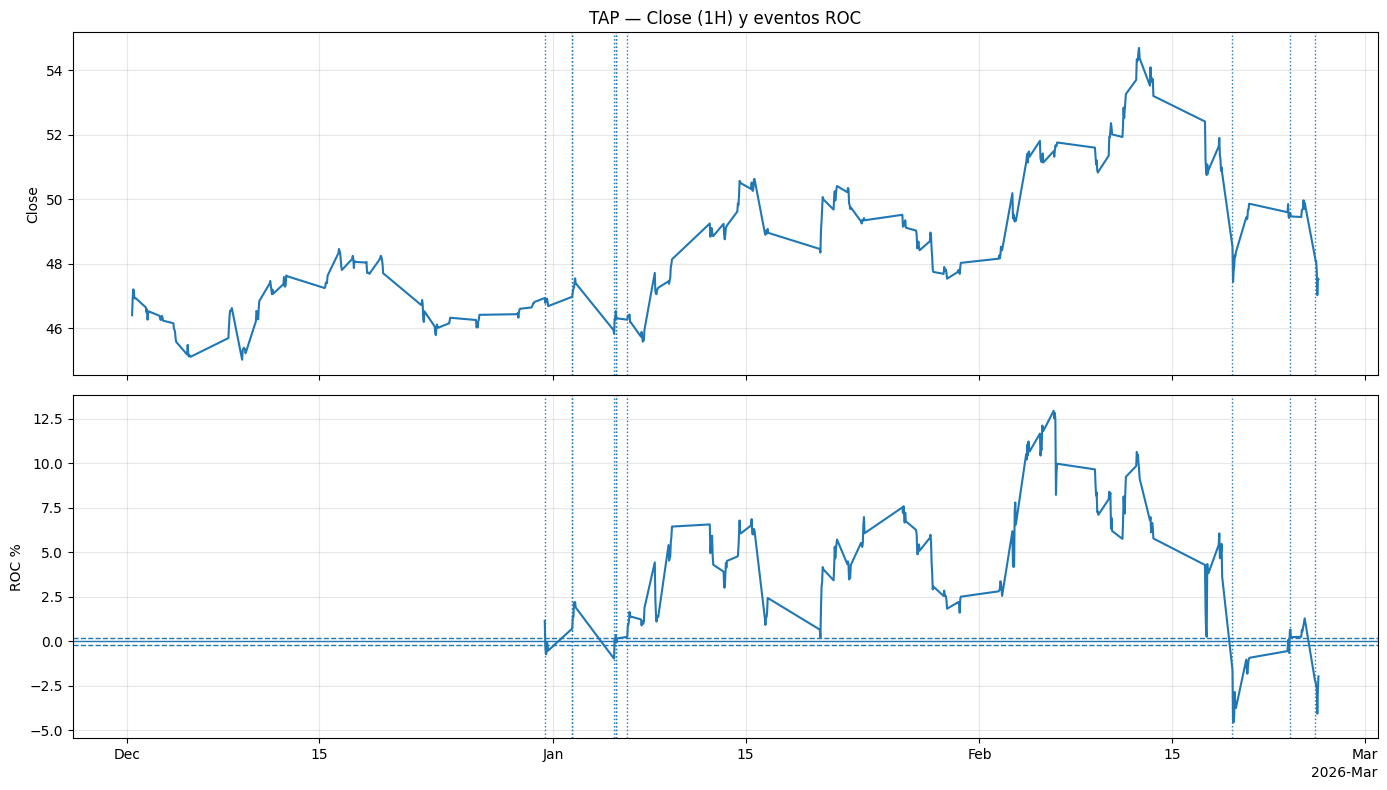

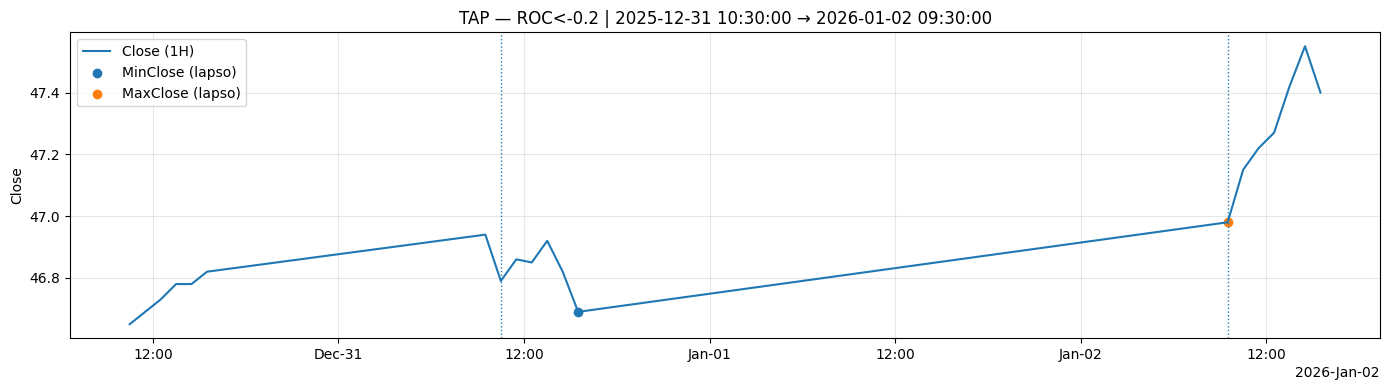

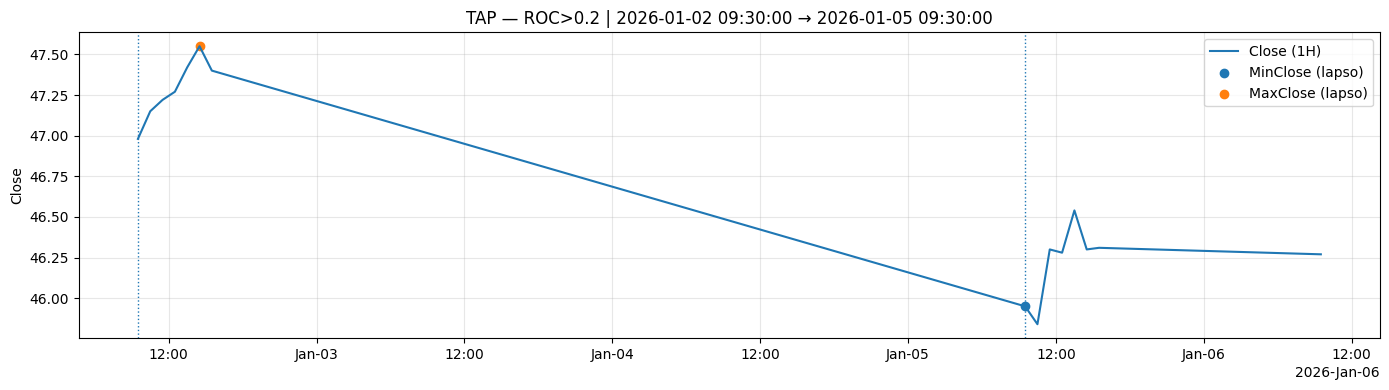

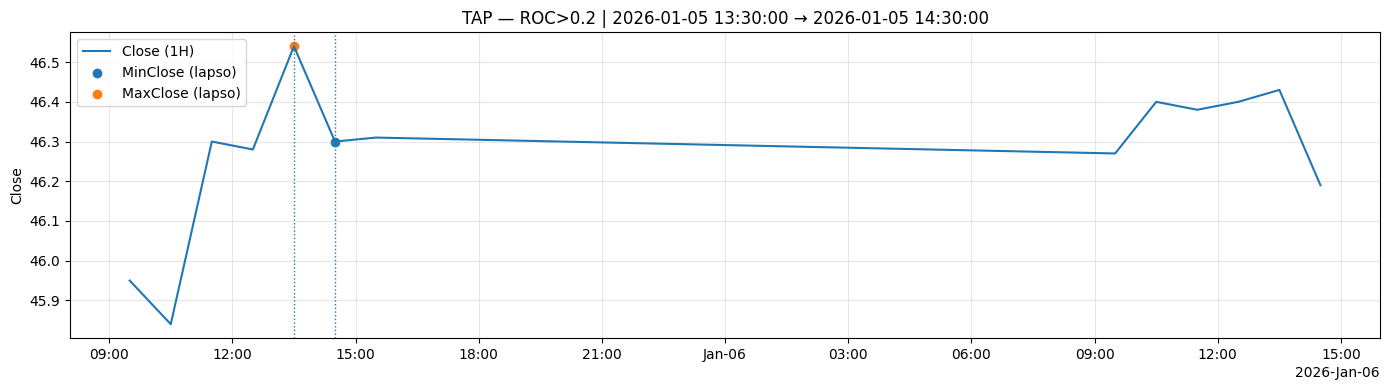

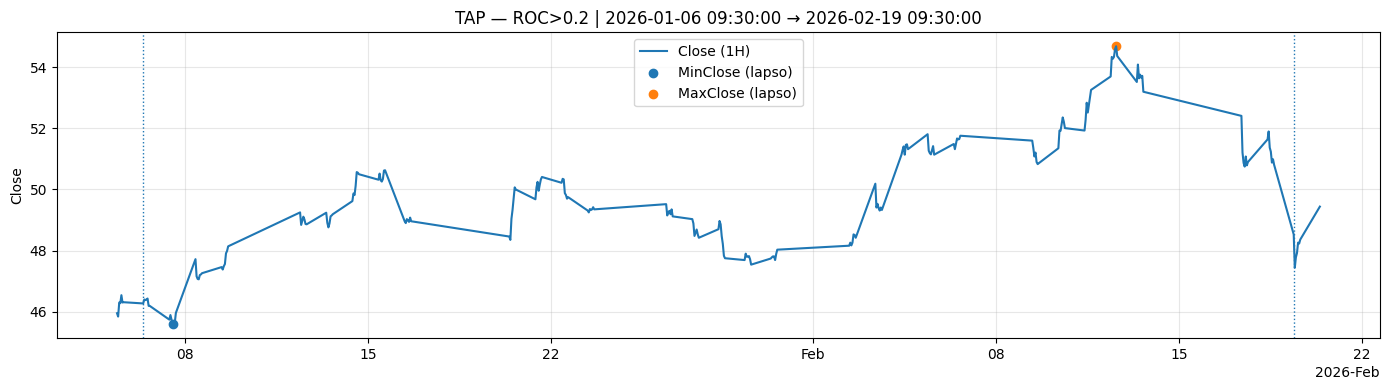

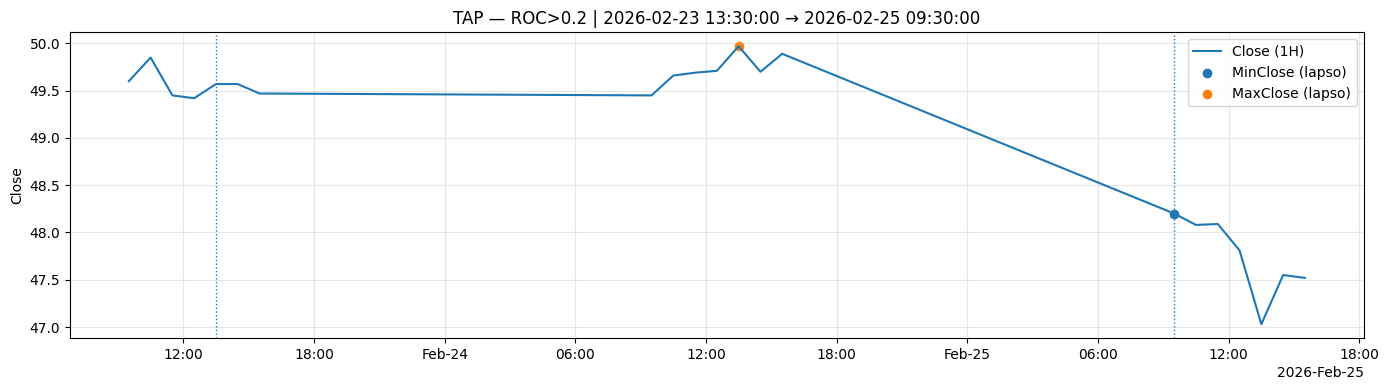

In [ ]:
# ============================================================
# Graficar (matplotlib) los eventos registrados para un ticker específico
# Requiere: events_ext_df (del script de eventos) con columnas:
#   ['Ticker','EventDateTime','ZeroDateTime','EventType','EventIndex', ...]
# Descarga 1H desde FMP, calcula ROC(144) y marca los eventos en el gráfico.
# ============================================================

#!/usr/bin/env python
try:
    from urllib.request import urlopen
except ImportError:
    from urllib2 import urlopen

import certifi, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone

# ---------------- CONFIG ----------------
API_KEY = "gulW74E75O2BjtTbmERXOInaTOD5BltA"
TICKER_FILTER = "TAP"     # <-- cambia aquí

START_DATE = "2024-01-01"  # <-- ajusta si quieres
END_DATE   = "2026-12-31"  # <-- ajusta si quieres

ROC_N = 144
THRESH = 0.2               # en % (0.2 = 0.2%)
EXCLUDE_TODAY = True

# Para graficar eventos individuales (ventanas)
PLOT_INDIVIDUAL_EVENTS = True
MAX_EVENT_PLOTS = 8        # limita cuántos eventos individuales graficar
PAD_HOURS = 24             # horas antes/después del lapso del evento
# --------------------------------------

def get_jsonparsed_data(url: str):
    response = urlopen(url, cafile=certifi.where())
    data = response.read().decode("utf-8")
    return json.loads(data)

def fetch_intraday_1h(symbol: str, api_key: str):
    url_stable = f"https://financialmodelingprep.com/stable/historical-chart/1hour?symbol={symbol}&apikey={api_key}"
    data = get_jsonparsed_data(url_stable)
    if not isinstance(data, list):
        url_v3 = f"https://financialmodelingprep.com/api/v3/historical-chart/1hour/{symbol}?apikey={api_key}"
        data = get_jsonparsed_data(url_v3)
    return data

def filter_date_range(df: pd.DataFrame, dt_col: str, start_date: str, end_date: str):
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date) + pd.Timedelta(days=1) - pd.Timedelta(microseconds=1)
    return df[(df[dt_col] >= start) & (df[dt_col] <= end)]

# --- Validaciones ---
if "events_ext_df" not in globals():
    raise ValueError("No existe events_ext_df en memoria. Corre primero el bloque que genera events_ext_df.")

TICKER_FILTER = str(TICKER_FILTER).strip().upper()

ev = events_ext_df.copy()
ev["Ticker"] = ev["Ticker"].astype(str).str.strip().str.upper()

# Convertir a datetime por si vinieran como texto
ev["EventDateTime"] = pd.to_datetime(ev["EventDateTime"], errors="coerce")
ev["ZeroDateTime"]  = pd.to_datetime(ev["ZeroDateTime"], errors="coerce")

ev_t = ev[(ev["Ticker"] == TICKER_FILTER)].dropna(subset=["EventDateTime","ZeroDateTime"]).copy()
ev_t = ev_t.sort_values("EventDateTime").reset_index(drop=True)

if ev_t.empty:
    raise ValueError(f"No hay eventos para {TICKER_FILTER} en events_ext_df.")

# --- Descargar precios 1H ---
raw = fetch_intraday_1h(TICKER_FILTER, API_KEY)
if not isinstance(raw, list) or len(raw) == 0:
    raise ValueError(f"Intraday vacío para {TICKER_FILTER} desde FMP.")

df_h = pd.DataFrame(raw)
if "date" not in df_h.columns or "close" not in df_h.columns:
    raise ValueError(f"Intraday para {TICKER_FILTER} no trae columnas esperadas. cols={list(df_h.columns)}")

df_h["datetime"] = pd.to_datetime(df_h["date"], errors="coerce")
df_h["close"] = pd.to_numeric(df_h["close"], errors="coerce")
df_h = df_h.dropna(subset=["datetime","close"]).sort_values("datetime").drop_duplicates(["datetime"], keep="last")
df_h = filter_date_range(df_h, "datetime", START_DATE, END_DATE)

if EXCLUDE_TODAY:
    today_utc = datetime.now(timezone.utc).date()
    df_h = df_h[df_h["datetime"].dt.date != today_utc]

if len(df_h) < (ROC_N + 5):
    raise ValueError(f"No hay suficientes velas 1H para calcular ROC({ROC_N}) en {TICKER_FILTER}. Velas: {len(df_h)}")

# --- Calcular ROC ---
df_h["roc"] = (df_h["close"] / df_h["close"].shift(ROC_N) - 1.0) * 100.0

# ============================================================
# GRÁFICO 1: Serie completa + marcas de eventos (precio y ROC)
# ============================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Precio
ax1.plot(df_h["datetime"], df_h["close"], label="Close (1H)")
ax1.set_title(f"{TICKER_FILTER} — Close (1H) y eventos ROC")
ax1.set_ylabel("Close")
ax1.grid(True, alpha=0.3)

# ROC
ax2.plot(df_h["datetime"], df_h["roc"], label=f"ROC({ROC_N}) %")
ax2.axhline(0, linewidth=1)
ax2.axhline(THRESH, linestyle="--", linewidth=1)
ax2.axhline(-THRESH, linestyle="--", linewidth=1)
ax2.set_ylabel("ROC %")
ax2.grid(True, alpha=0.3)

# Marcar eventos
for _, r in ev_t.iterrows():
    # líneas verticales inicio y fin del lapso
    ax1.axvline(r["EventDateTime"], linestyle=":", linewidth=1)
    ax1.axvline(r["ZeroDateTime"], linestyle=":", linewidth=1)
    ax2.axvline(r["EventDateTime"], linestyle=":", linewidth=1)
    ax2.axvline(r["ZeroDateTime"], linestyle=":", linewidth=1)

# Formato de fechas
ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
ax2.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax2.xaxis.get_major_locator()))
plt.tight_layout()
plt.show()

# ============================================================
# GRÁFICO 2 (opcional): Ventanas por evento (zoom) con min/max del lapso
# ============================================================

if PLOT_INDIVIDUAL_EVENTS:
    # si hay muchísimos eventos, limitamos
    ev_plot = ev_t.head(MAX_EVENT_PLOTS).copy()

    for k, r in ev_plot.iterrows():
        t0 = r["EventDateTime"] - pd.Timedelta(hours=PAD_HOURS)
        t1 = r["ZeroDateTime"]  + pd.Timedelta(hours=PAD_HOURS)

        w = df_h[(df_h["datetime"] >= t0) & (df_h["datetime"] <= t1)].copy()
        if w.empty:
            continue

        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(w["datetime"], w["close"], label="Close (1H)")
        ax.axvline(r["EventDateTime"], linestyle=":", linewidth=1)
        ax.axvline(r["ZeroDateTime"], linestyle=":", linewidth=1)
        ax.set_title(f"{TICKER_FILTER} — {r.get('EventType','')} | {r['EventDateTime']} → {r['ZeroDateTime']}")
        ax.set_ylabel("Close")
        ax.grid(True, alpha=0.3)

        # Si existen MinClose/MaxClose en events_ext_df, marcarlos
        if "MinCloseDateTime" in r and "MinClose" in r and pd.notna(r["MinCloseDateTime"]):
            ax.scatter([pd.to_datetime(r["MinCloseDateTime"])], [r["MinClose"]], label="MinClose (lapso)")
        if "MaxCloseDateTime" in r and "MaxClose" in r and pd.notna(r["MaxCloseDateTime"]):
            ax.scatter([pd.to_datetime(r["MaxCloseDateTime"])], [r["MaxClose"]], label="MaxClose (lapso)")

        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
        ax.legend()
        plt.tight_layout()
        plt.show()